# Reasoning and Rationale Tag Distributions

Purpose: summarize keyword-tier coverage in the tagged reasoning and rationale corpora, then attach those tags to replay rows for association models.

Inputs:
- `trails/rationale_trails_tagged.csv` and `trails/reasoning_trails_tagged.csv` from `reasoning_rationale_stems.ipynb`.
- Replay CSV data loaded with `load_replay_data()`.

Unit of analysis:
- Heatmaps summarize tagged trail rows by `(condition, replay_model)`.
- Regressions use one replay row per `(game_id, player_id, turn, condition, repetition, replay_model)`.

Definitions:
- `reasoning` is assistant reasoning/text extracted from replay JSON messages.
- `rationale` is the replay CSV `replayRationale` field.
- Tier columns are binary keyword flags defined in the `TIERS` dictionary.


In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from shared.plot_utilities import setup_notebook_display, plot_replay_direction_heatmap
from nuke.utils.load_replay_data import (
    _KNOWN_CONDITIONS,
    REPLAY_TAG_JOIN_KEYS,
    canonical_condition_name,
    add_canonical_replay_model,
    filter_complete_replay_models,
    load_replay_data,
    safe_tier_name,
    tier_source_columns,
)

setup_notebook_display()

TIERS = [
    "Explicit",
    "Nuclear",
    "Crisis_Urgency",
    "Simulation_Game",
]

TRAILS_DIR = Path('trails')
CONDITION_ORDER = list(_KNOWN_CONDITIONS)


## 1. Load Tagged Trails and Replay Metadata

Load tagged reasoning/rationale trail tables, canonicalize replay model names, and attach tag columns to the full replay table with explicit missing-coverage handling.

In [2]:
rat = pd.read_csv(TRAILS_DIR / 'rationale_trails_tagged.csv')
rea = pd.read_csv(TRAILS_DIR / 'reasoning_trails_tagged.csv')
rat['corpus'] = 'rationale'
rea['corpus'] = 'reasoning'

for frame in (rat, rea):
    frame = add_canonical_replay_model(frame)
    frame['condition'] = frame['condition'].map(canonical_condition_name)
    frame['condition'] = pd.Categorical(frame['condition'], categories=CONDITION_ORDER, ordered=True)

TIER_SOURCE_COLS = tier_source_columns(TIERS)

replay = load_replay_data()
replay = add_canonical_replay_model(replay)
replay, MODEL_ORDER = filter_complete_replay_models(replay)
replay['condition'] = pd.Categorical(replay['condition'], categories=CONDITION_ORDER, ordered=True)

# Fully crossed: left-join tier tags onto full replay.
# Do NOT fillna(0) - keep NaN so model x condition cells without trails
# show as NA rather than a misleading 0 % hit-rate.
rat_full = replay.merge(rat[REPLAY_TAG_JOIN_KEYS + TIER_SOURCE_COLS], on=REPLAY_TAG_JOIN_KEYS, how='left')
rea_full = replay.merge(rea[REPLAY_TAG_JOIN_KEYS + TIER_SOURCE_COLS], on=REPLAY_TAG_JOIN_KEYS, how='left')

print(f'Rationale rows: {len(rat):,}')
print(f'Reasoning rows: {len(rea):,}')
print(f'Full replay after complete-model filter: {len(replay):,}')
print(f'Models (complete catalog order): {MODEL_ORDER}')
print(f'Conditions           : {CONDITION_ORDER}')


✓ Loaded 37,440 rows from 96 files
  Conditions   : original, no-rationale, high-stakes, high-stakes-no-rationale, ethical, ethical-high-stakes, ethical-no-rationale, high-stakes-no-rationale-ethical
  Replay models: DeepSeek-V3.2, DeepSeek-V4, GLM-4.7, GLM-5.1, Gemma-4, Kimi-K2.5, Kimi-K2.6, MiniMax-M2.7, Mistral-Small-4, Qwen-3.5, Qwen-3.6-27B, gpt-oss-120b

  Rows per condition × replay model:
  ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                        DeepSeek-V3.2      DeepSeek-V4          GLM-4.7          GLM-5.1          Gemma-4        Kimi-K2.5        Kimi-K2.6     MiniMax-M2.7  Mistral-Small-4         Qwen-3.5     Qwen-3.6-27B     gpt-oss-120b            Total
  ──────────────────────────────────────────────────────────────────────────────────

## 2. Aggregate Tag Hit Rates

For each tier, compute the percentage of tagged rows with a hit by `(replay_model, condition)`. Cells with no tagged rows remain missing rather than being treated as zero hit-rate.

In [3]:
def tier_grid(frame: pd.DataFrame, tier: str) -> pd.DataFrame:
    """Return hit-rate percentages with rows = MODEL_ORDER + ['Grand avg'], cols = CONDITION_ORDER."""
    col = f'tier_{tier}'
    grp = frame.groupby(['replay_model_canonical', 'condition'], observed=True)[col]
    rate = (grp.mean() * 100).unstack('condition')
    # count() excludes NaN -> only rows that actually have trails.
    counts = grp.count().unstack('condition')
    # Fully shape to catalog order; missing (model, cond) cells become NaN / 0.
    rate = rate.reindex(index=MODEL_ORDER, columns=CONDITION_ORDER)
    counts = counts.reindex(index=MODEL_ORDER, columns=CONDITION_ORDER).fillna(0).astype(int)
    # Zero-sample cells -> NaN so seaborn greys them.
    rate = rate.where(counts > 0)
    # Un-weighted mean across models (NaN-safe).
    grand = rate.mean(axis=0, skipna=True)
    grand.name = 'Grand avg'
    rate = pd.concat([rate, grand.to_frame().T])
    return rate

## 3. Plot Tag Hit-Rate Heatmaps

Render one heatmap per tier with rationale and reasoning corpora side by side. Annotations show hit-rate percentages.

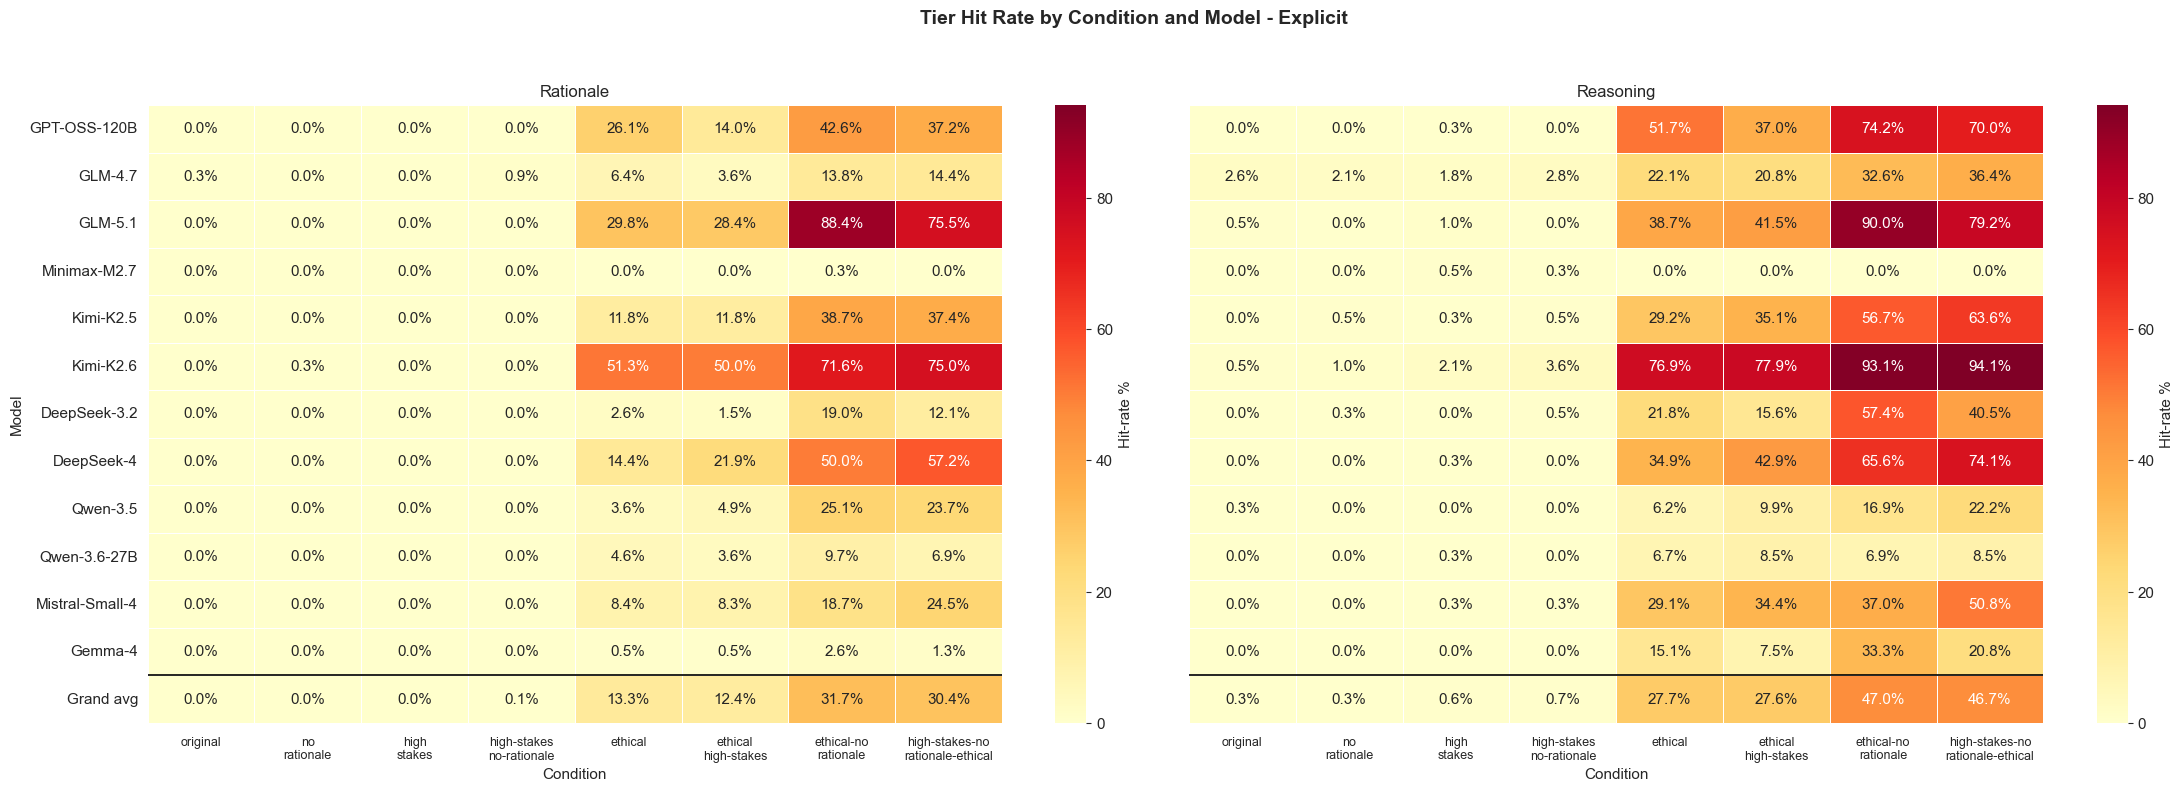

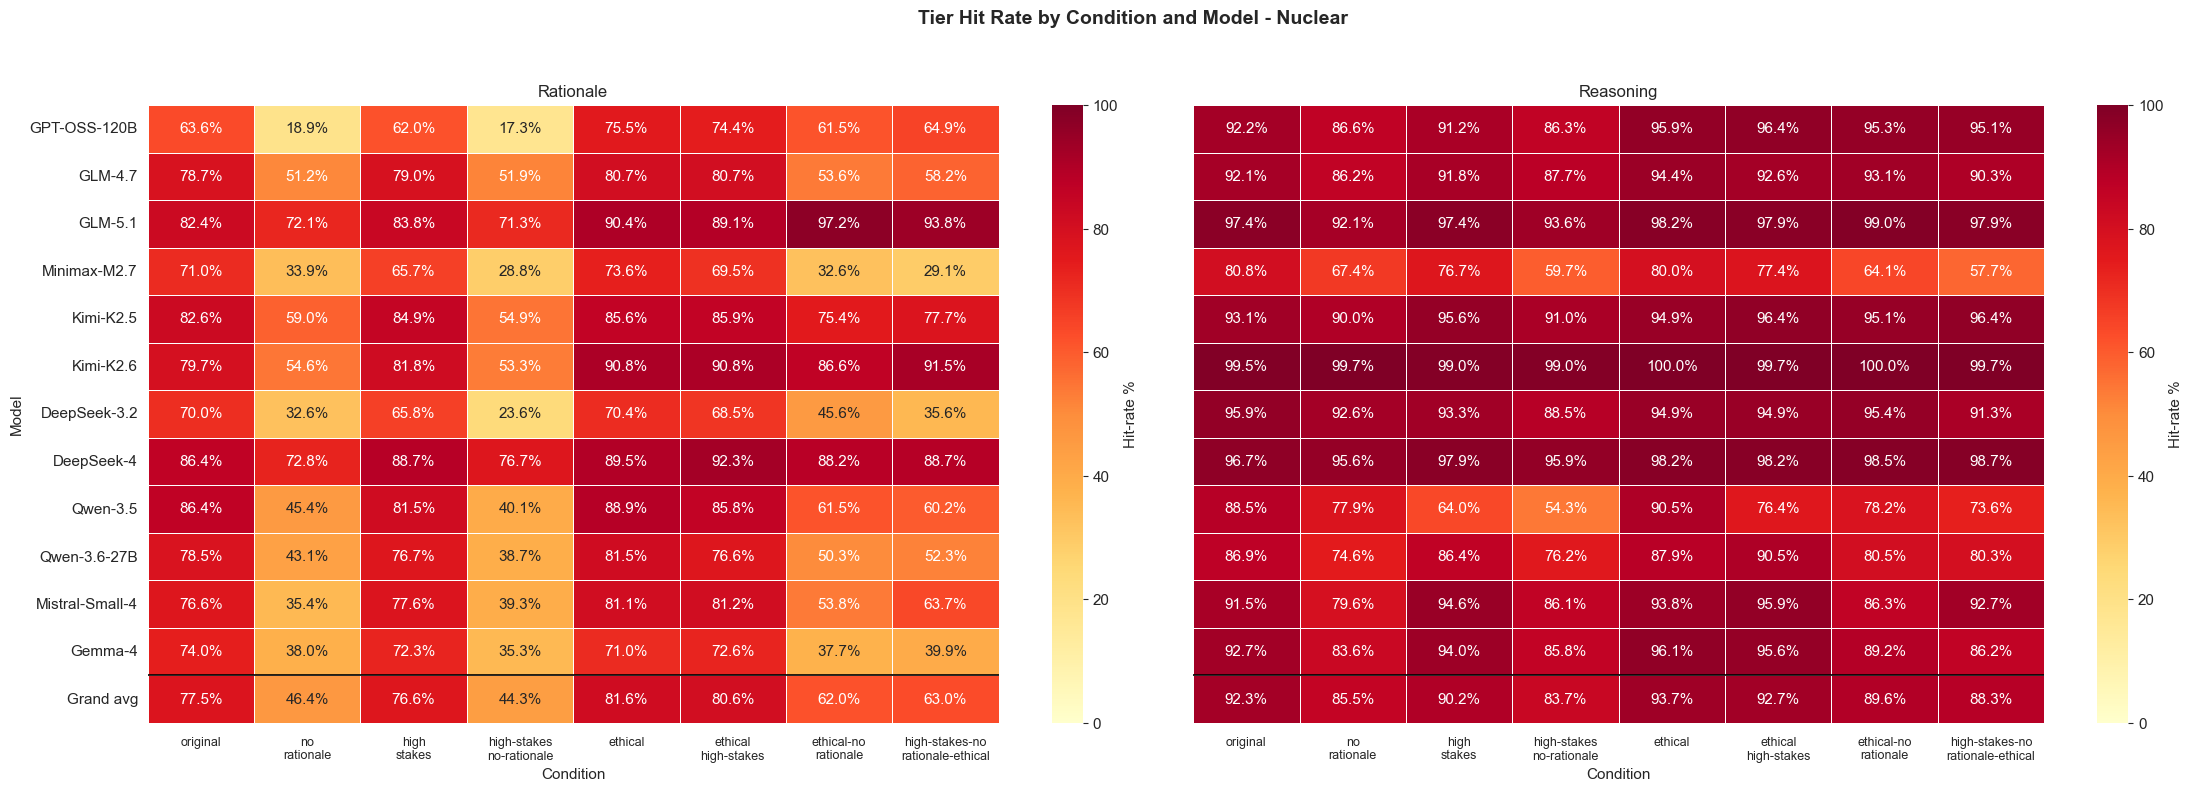

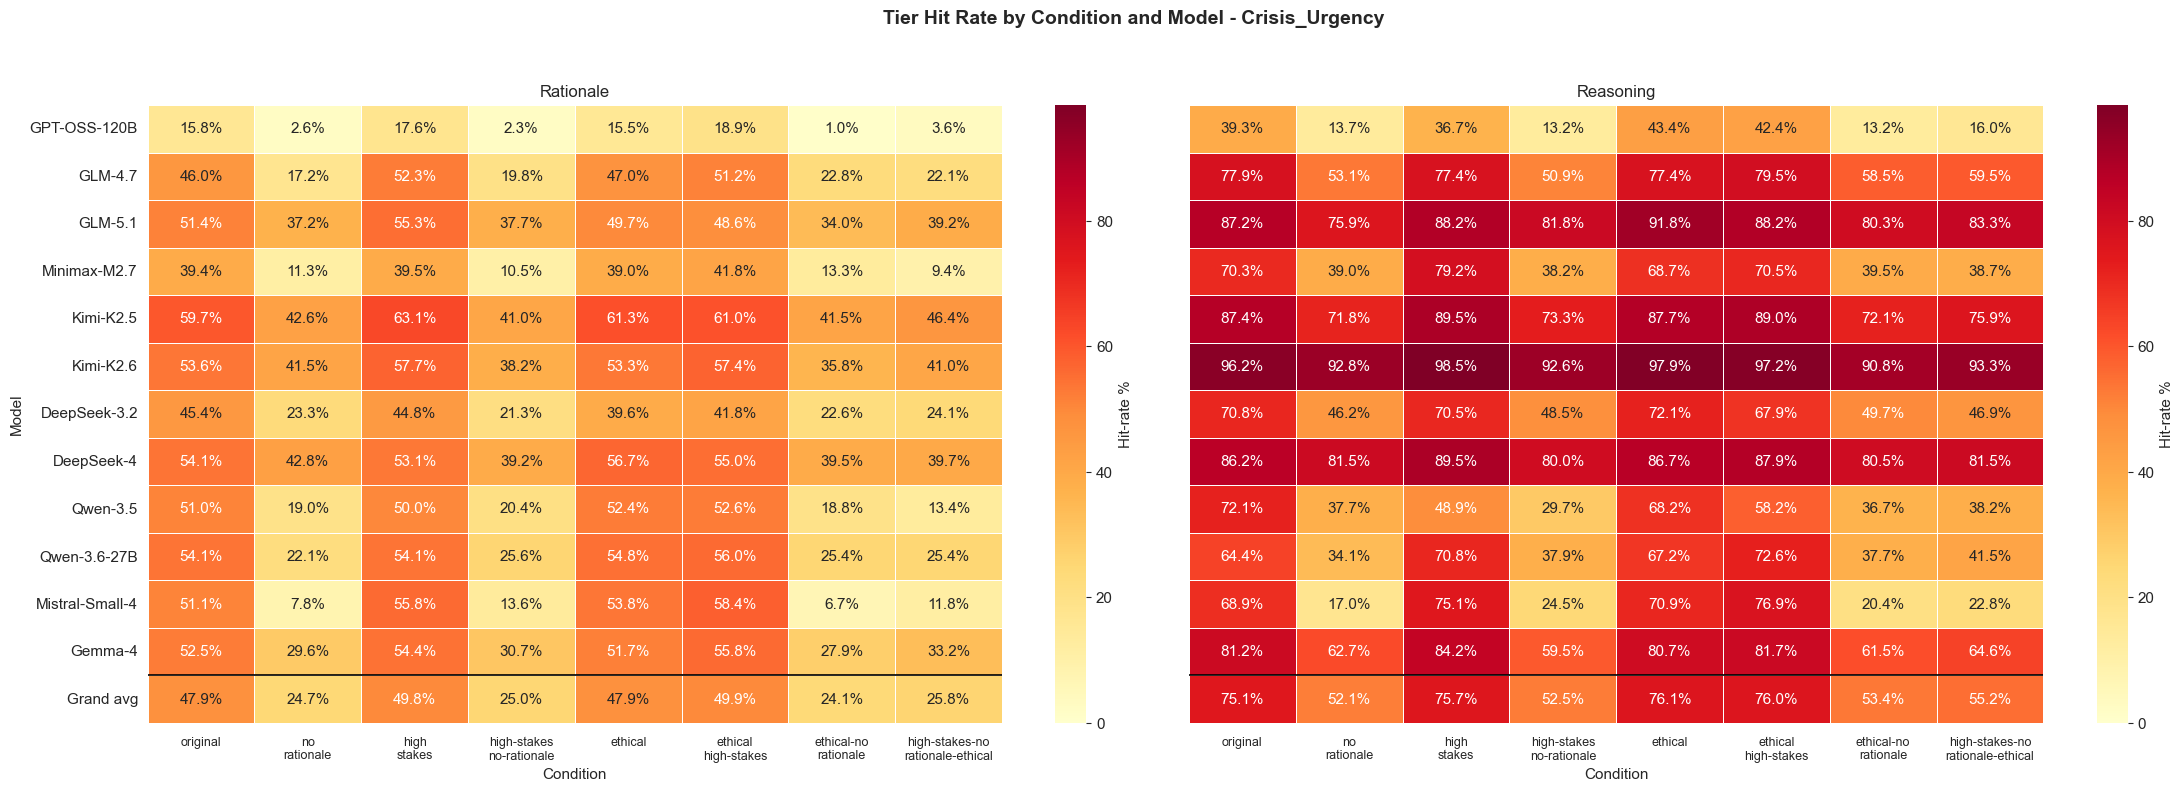

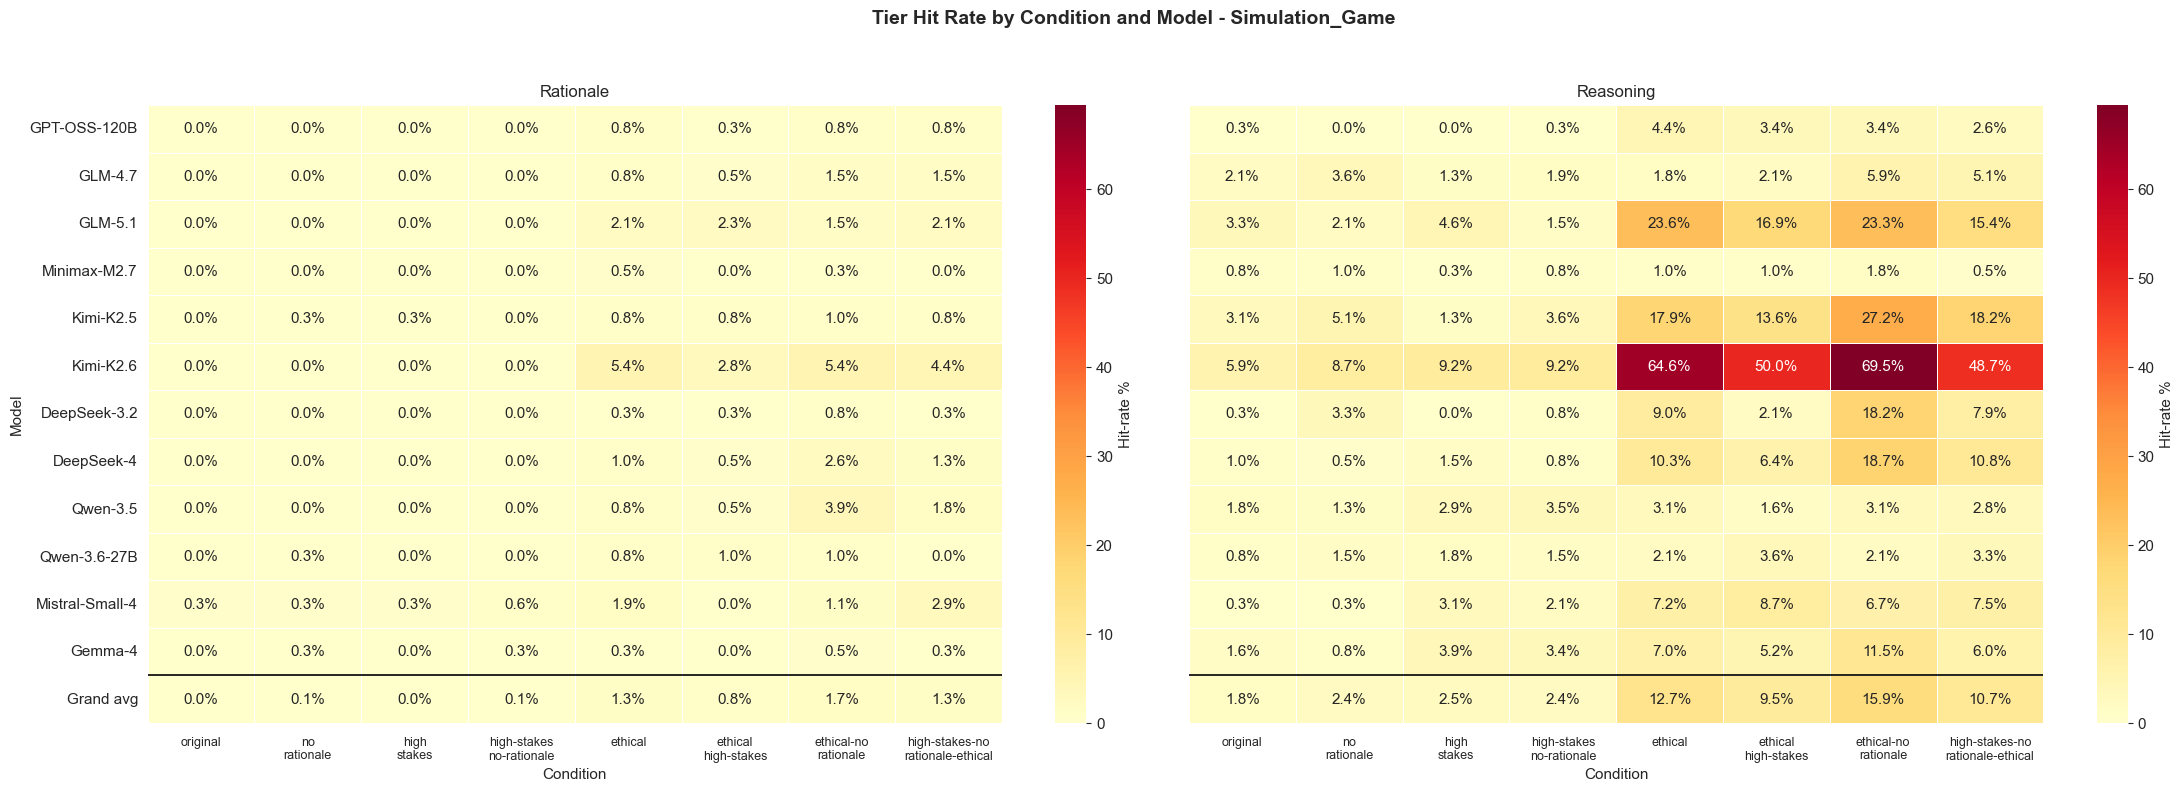

In [4]:
def _two_line_condition_label(label: str) -> str:
    # Same split idiom as shared.plot_utilities._two_line_condition_label.
    parts = str(label).split('-')
    if len(parts) <= 1:
        return str(label)
    candidates = []
    for split_at in range(1, len(parts)):
        left = '-'.join(parts[:split_at])
        right = '-'.join(parts[split_at:])
        candidates.append((max(len(left), len(right)), abs(len(left) - len(right)), left, right))
    _, _, left, right = min(candidates)
    return f'{left}\n{right}'

def _annot(rate_df: pd.DataFrame) -> np.ndarray:
    out = np.empty(rate_df.shape, dtype=object)
    for i in range(rate_df.shape[0]):
        for j in range(rate_df.shape[1]):
            rate = rate_df.iat[i, j]
            if pd.isna(rate):
                out[i, j] = 'NA'
            else:
                out[i, j] = f'{rate:.1f}%'
    return out

def plot_tier(tier: str) -> None:
    rat_rate = tier_grid(rat_full, tier)
    rea_rate = tier_grid(rea_full, tier)
    vmax = float(np.nanmax([rat_rate.values, rea_rate.values])) if len(MODEL_ORDER) else 100.0
    vmax = max(vmax, 1.0)  # avoid degenerate colormap

    fig, axes = plt.subplots(
        1, 2,
        figsize=(len(CONDITION_ORDER) * 1.3 * 2 + 2, (len(MODEL_ORDER) + 1) * 0.45 + 2.2),
        sharey=True,
    )
    fig.suptitle(f'Tier Hit Rate by Condition and Model - {tier}', fontsize=14, fontweight='bold')

    for ax, (name, rate_df) in zip(axes, [
        ('Rationale', rat_rate),
        ('Reasoning', rea_rate),
    ]):
        sns.heatmap(
            rate_df,
            annot=_annot(rate_df),
            fmt='',
            cmap='YlOrRd',
            vmin=0, vmax=vmax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Hit-rate %'},
            ax=ax,
        )
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Condition')
        ax.set_ylabel('Model' if name == 'Rationale' else '')
        ax.set_xticks(np.arange(len(CONDITION_ORDER)) + 0.5)
        ax.set_xticklabels([_two_line_condition_label(c) for c in CONDITION_ORDER], rotation=0, ha='center', va='top')
        ax.tick_params(axis='x', labelsize=9, pad=6)
        # Separate the Grand avg row with a thicker horizontal line.
        ax.axhline(len(MODEL_ORDER), color='black', linewidth=1.2)

    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

for tier in TIERS:
    plot_tier(tier)

## 4. Tag-Conditioned Replay Direction

When a tag is present, summarize whether the replay model chose a lower, same, or higher nuke value than the pre-replay baseline.

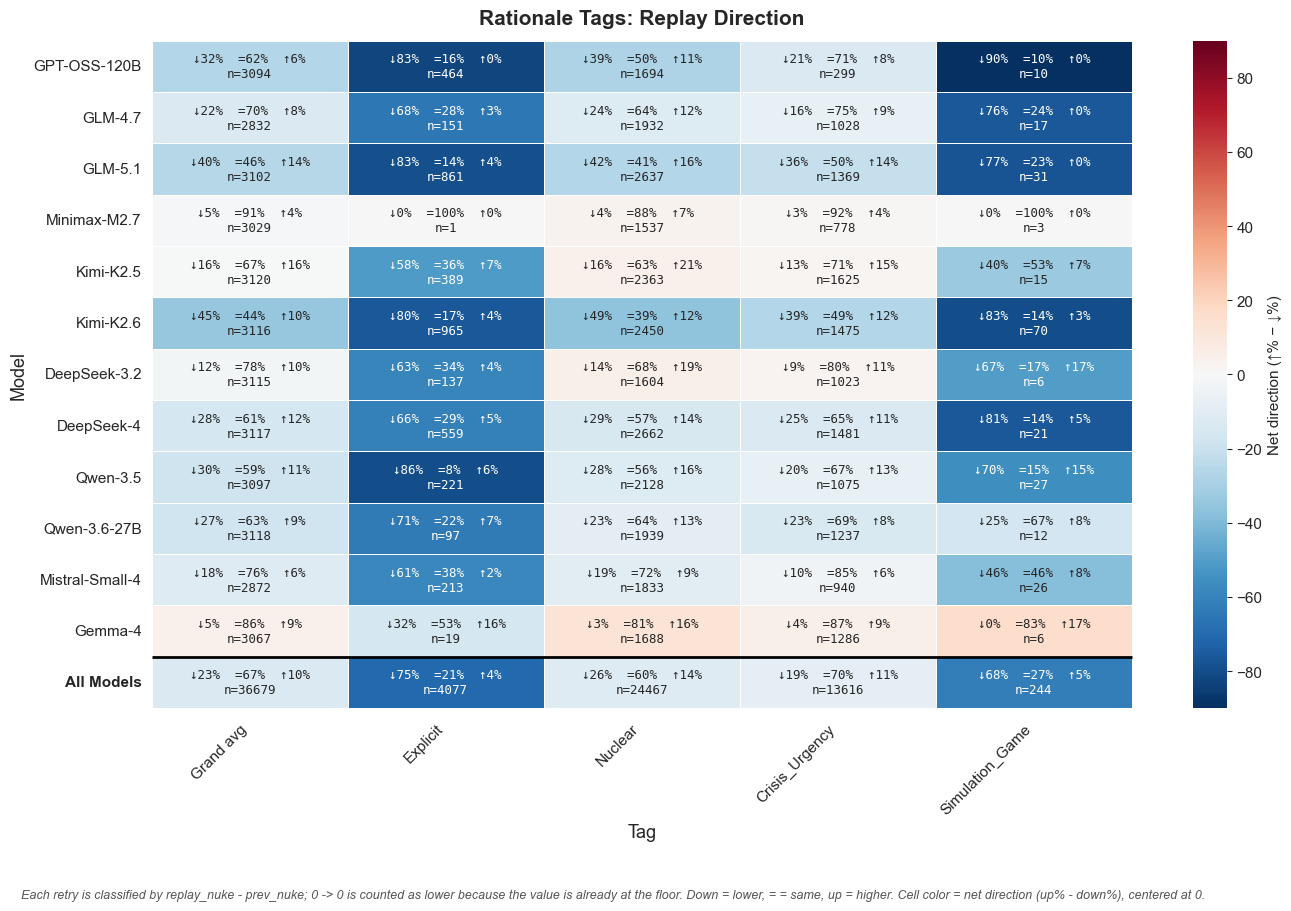

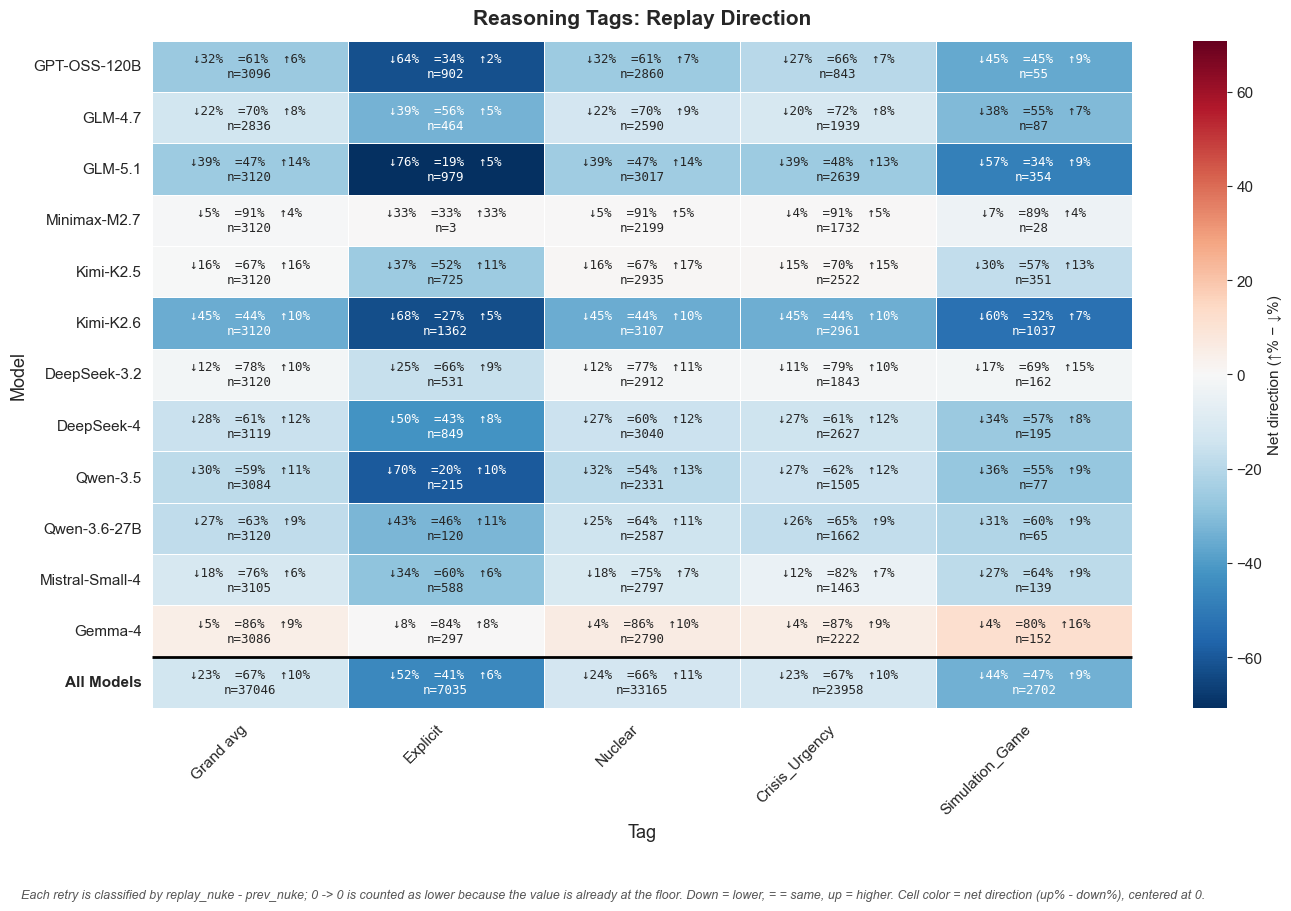

In [5]:
def add_zero_floor_direction_baseline(df: pd.DataFrame, metric: str = 'replay_nuke', compare_to: str = 'prev_nuke'):
    """Treat kept-at-zero values as decreases for direction summaries.

    The raw replay values stay unchanged; this only creates a plotting baseline
    that makes 0 -> 0 classify as lower because the metric is already at its floor.
    """
    out = df.copy()
    direction_compare = f'{compare_to}_zero_floor_direction'
    out[direction_compare] = out[compare_to]
    zero_floor_same = out[metric].eq(0) & out[compare_to].eq(0)
    out.loc[zero_floor_same, direction_compare] = 1
    return out, direction_compare

rat_direction, direction_compare = add_zero_floor_direction_baseline(rat_full)
rea_direction, _ = add_zero_floor_direction_baseline(rea_full)

direction_footnote = (
    'Each retry is classified by replay_nuke - prev_nuke; 0 -> 0 is counted as lower '
    'because the value is already at the floor. Down = lower, = = same, up = higher. '
    'Cell color = net direction (up% - down%), centered at 0.'
)

fig, ax = plot_replay_direction_heatmap(
    rat_direction,
    metric='replay_nuke',
    compare_to=direction_compare,
    model_order=MODEL_ORDER,
    presence_cols=TIER_SOURCE_COLS,
    presence_labels=TIERS,
    grand_average_col=True,
    title='Rationale Tags: Replay Direction',
    footnote=direction_footnote,
)

fig, ax = plot_replay_direction_heatmap(
    rea_direction,
    metric='replay_nuke',
    compare_to=direction_compare,
    model_order=MODEL_ORDER,
    presence_cols=TIER_SOURCE_COLS,
    presence_labels=TIERS,
    grand_average_col=True,
    title='Reasoning Tags: Replay Direction',
    footnote=direction_footnote,
)

## 5. Reasoning x Rationale Conditional Tag Overlap

For rows with both reasoning and rationale tags, compute conditional overlap rates instead of percentages over all matched rows. These matrices answer questions like: when a reasoning tier appears, how often does each rationale tier appear too?


,reasoning_hits,reasoning_hit_rate,rationale_hits,rationale_hit_rate,same_tier_overlap,P(rationale | reasoning),P(reasoning | rationale)
tier,,,,,,,
Explicit,6981,19.1%,4077,11.1%,3786,54.2%,92.9%
Nuclear,32827,89.6%,24439,66.7%,23716,72.2%,97.0%
Crisis_Urgency,23764,64.9%,13603,37.1%,12141,51.1%,89.3%
Simulation_Game,2686,7.3%,244,0.7%,111,4.1%,45.5%


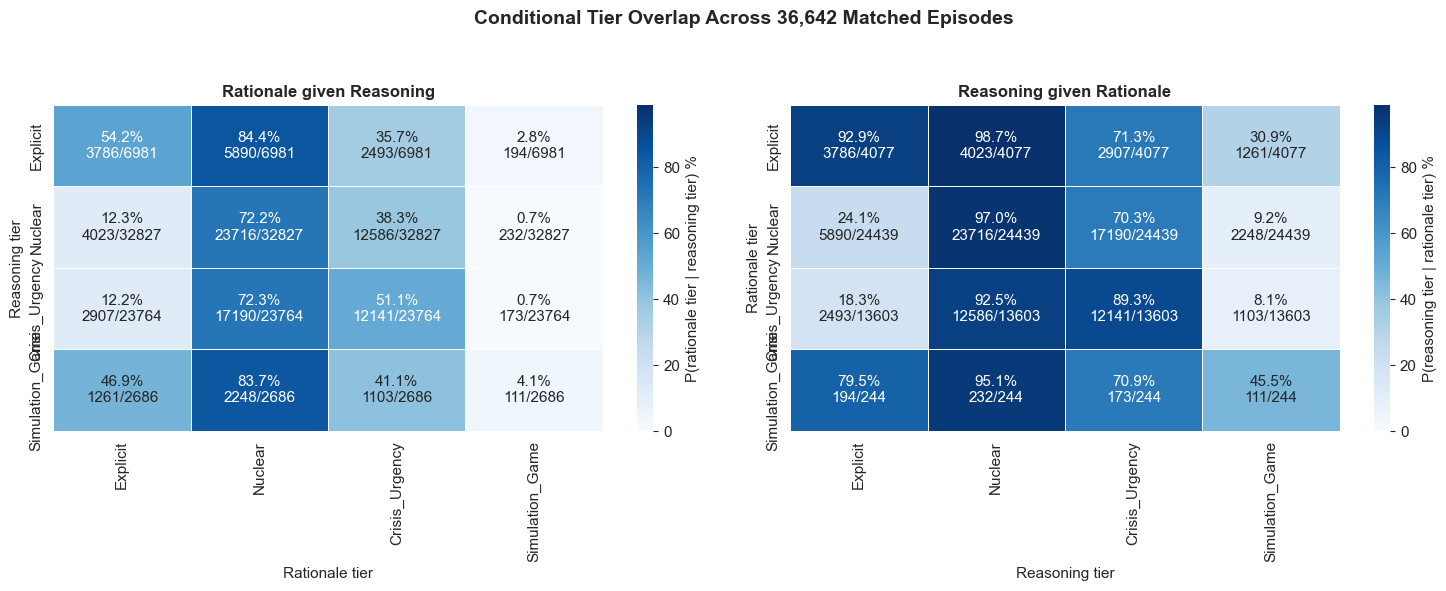

In [6]:
# Inner-join reasoning + rationale for conditional overlap.
rat_co = rat[REPLAY_TAG_JOIN_KEYS + TIER_SOURCE_COLS].rename(
    columns={c: f'rat_{safe_tier_name(t)}' for t, c in zip(TIERS, TIER_SOURCE_COLS)}
)
rea_co = rea[REPLAY_TAG_JOIN_KEYS + TIER_SOURCE_COLS].rename(
    columns={c: f'rea_{safe_tier_name(t)}' for t, c in zip(TIERS, TIER_SOURCE_COLS)}
)
both = rat_co.merge(rea_co, on=REPLAY_TAG_JOIN_KEYS, how='inner')

# Build conditional matrices. Rows are the conditioning tier in the named corpus;
# columns are the overlapping tier in the other corpus.
rat_given_rea_pct = pd.DataFrame(index=TIERS, columns=TIERS, dtype=float)
rea_given_rat_pct = pd.DataFrame(index=TIERS, columns=TIERS, dtype=float)
rat_given_rea_num = pd.DataFrame(index=TIERS, columns=TIERS, dtype=int)
rea_given_rat_num = pd.DataFrame(index=TIERS, columns=TIERS, dtype=int)
rat_given_rea_den = pd.Series(index=TIERS, dtype=int)
rea_given_rat_den = pd.Series(index=TIERS, dtype=int)

for rt in TIERS:
    rea_hit = both[f'rea_{safe_tier_name(rt)}'] == 1
    rea_den = int(rea_hit.sum())
    rat_given_rea_den.loc[rt] = rea_den
    for ct in TIERS:
        rat_hit = both[f'rat_{safe_tier_name(ct)}'] == 1
        numerator = int((rea_hit & rat_hit).sum())
        rat_given_rea_num.loc[rt, ct] = numerator
        rat_given_rea_pct.loc[rt, ct] = (numerator / rea_den * 100) if rea_den else np.nan

for rt in TIERS:
    rat_hit = both[f'rat_{safe_tier_name(rt)}'] == 1
    rat_den = int(rat_hit.sum())
    rea_given_rat_den.loc[rt] = rat_den
    for ct in TIERS:
        rea_hit = both[f'rea_{safe_tier_name(ct)}'] == 1
        numerator = int((rat_hit & rea_hit).sum())
        rea_given_rat_num.loc[rt, ct] = numerator
        rea_given_rat_pct.loc[rt, ct] = (numerator / rat_den * 100) if rat_den else np.nan

def _conditional_annot(pct_df: pd.DataFrame, num_df: pd.DataFrame, den: pd.Series) -> np.ndarray:
    out = np.empty(pct_df.shape, dtype=object)
    for i, row_tier in enumerate(pct_df.index):
        denominator = int(den.loc[row_tier])
        for j, _ in enumerate(pct_df.columns):
            pct = pct_df.iat[i, j]
            numerator = int(num_df.iat[i, j])
            if pd.isna(pct):
                out[i, j] = 'NA'
            else:
                out[i, j] = f'{pct:.1f}%\n{numerator}/{denominator}'
    return out

# Compact same-tier summary for quick reading of the key diagonal overlaps.
summary_rows = []
for tier in TIERS:
    safe = safe_tier_name(tier)
    rea_count = int((both[f'rea_{safe}'] == 1).sum())
    rat_count = int((both[f'rat_{safe}'] == 1).sum())
    overlap_count = int(((both[f'rea_{safe}'] == 1) & (both[f'rat_{safe}'] == 1)).sum())
    summary_rows.append({
        'tier': tier,
        'reasoning_hits': rea_count,
        'reasoning_hit_rate': rea_count / len(both) * 100 if len(both) else np.nan,
        'rationale_hits': rat_count,
        'rationale_hit_rate': rat_count / len(both) * 100 if len(both) else np.nan,
        'same_tier_overlap': overlap_count,
        'P(rationale | reasoning)': overlap_count / rea_count * 100 if rea_count else np.nan,
        'P(reasoning | rationale)': overlap_count / rat_count * 100 if rat_count else np.nan,
    })

conditional_overlap_summary = pd.DataFrame(summary_rows).set_index('tier')
display(
    conditional_overlap_summary.style.format({
        'reasoning_hit_rate': '{:.1f}%',
        'rationale_hit_rate': '{:.1f}%',
        'P(rationale | reasoning)': '{:.1f}%',
        'P(reasoning | rationale)': '{:.1f}%',
    })
)

vmax = float(np.nanmax([rat_given_rea_pct.values, rea_given_rat_pct.values])) if len(both) else 100.0
vmax = max(vmax, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
plots = [
    (
        axes[0],
        rat_given_rea_pct,
        _conditional_annot(rat_given_rea_pct, rat_given_rea_num, rat_given_rea_den),
        'Rationale given Reasoning',
        'Rationale tier',
        'Reasoning tier',
        'P(rationale tier | reasoning tier) %',
    ),
    (
        axes[1],
        rea_given_rat_pct,
        _conditional_annot(rea_given_rat_pct, rea_given_rat_num, rea_given_rat_den),
        'Reasoning given Rationale',
        'Reasoning tier',
        'Rationale tier',
        'P(reasoning tier | rationale tier) %',
    ),
]

for ax, pct_df, annot, title, xlabel, ylabel, cbar_label in plots:
    sns.heatmap(
        pct_df,
        annot=annot,
        fmt='',
        cmap='Blues',
        vmin=0, vmax=vmax,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': cbar_label},
        ax=ax,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

fig.suptitle(f'Conditional Tier Overlap Across {len(both):,} Matched Episodes', fontsize=14, fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()
